INFO:Dataset loaded with shape: (1000, 27)
INFO:Duplicates removed: 0
INFO:Rows dropped due to invalid dates: 0
INFO:Outliers capped for Sales
INFO:Outliers capped for Profit
INFO:Outliers capped for Discount
INFO:Outliers capped for Quantity
INFO:Outliers capped for Shipping Cost
INFO:Descriptive statistics:
       Discount     记录数           Order Date       Profit     Quantity  \
count    1000.0  1000.0                 1000  1000.000000  1000.000000   
mean        0.0     1.0  2013-04-18 11:52:48    19.569505     3.768500   
min         0.0     1.0  2011-01-07 00:00:00     0.000000     1.000000   
25%         0.0     1.0  2012-04-18 00:00:00     4.997325     2.000000   
50%         0.0     1.0  2013-06-13 00:00:00    10.686450     3.000000   
75%         0.0     1.0  2014-04-28 00:00:00    27.444050     5.000000   
max         0.0     1.0  2014-12-29 00:00:00    61.114137     9.500000   
std         0.0     0.0                  NaN    19.916730     2.126542   

             Row ID   

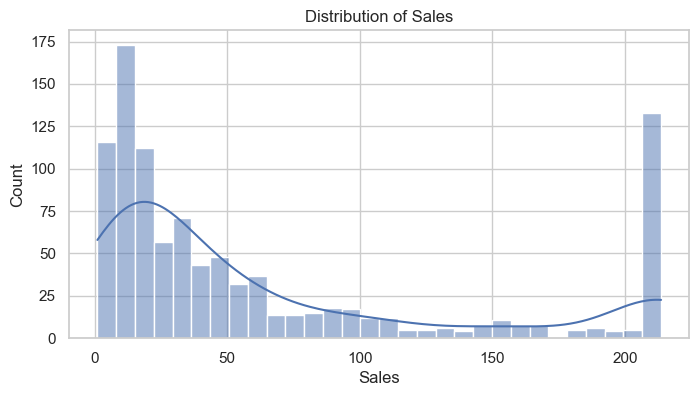

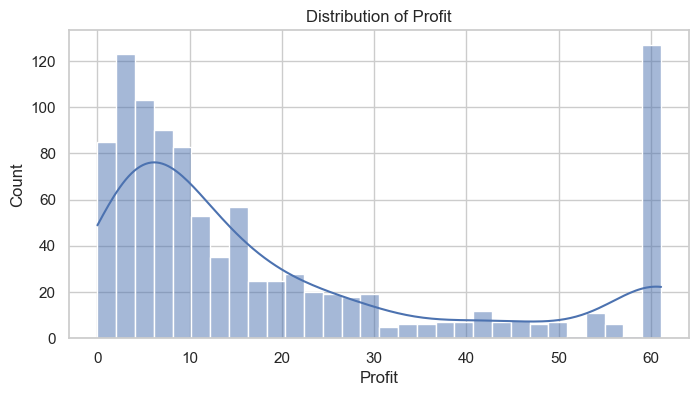

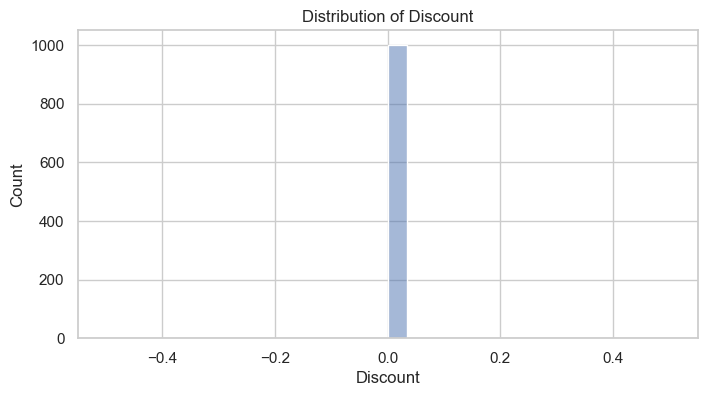

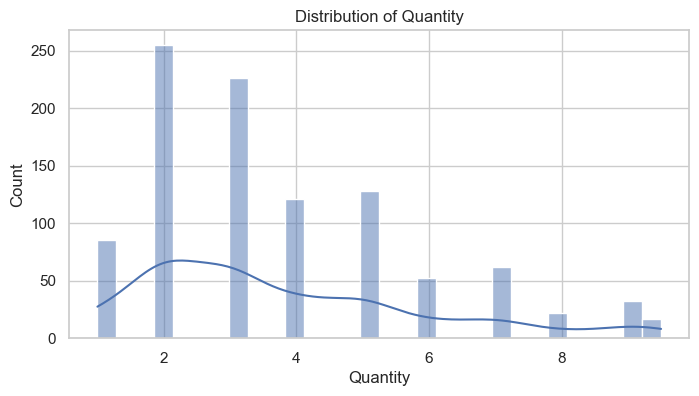

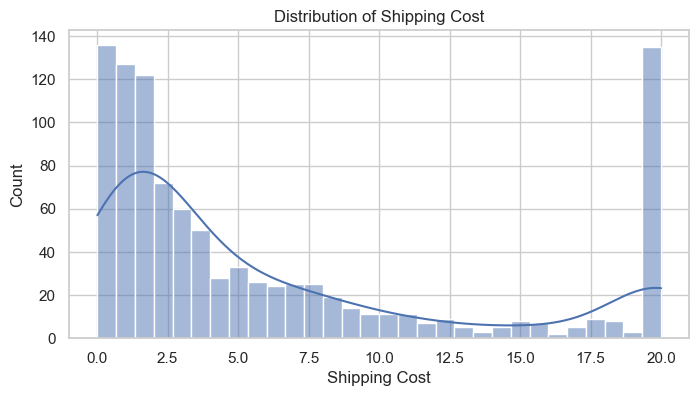

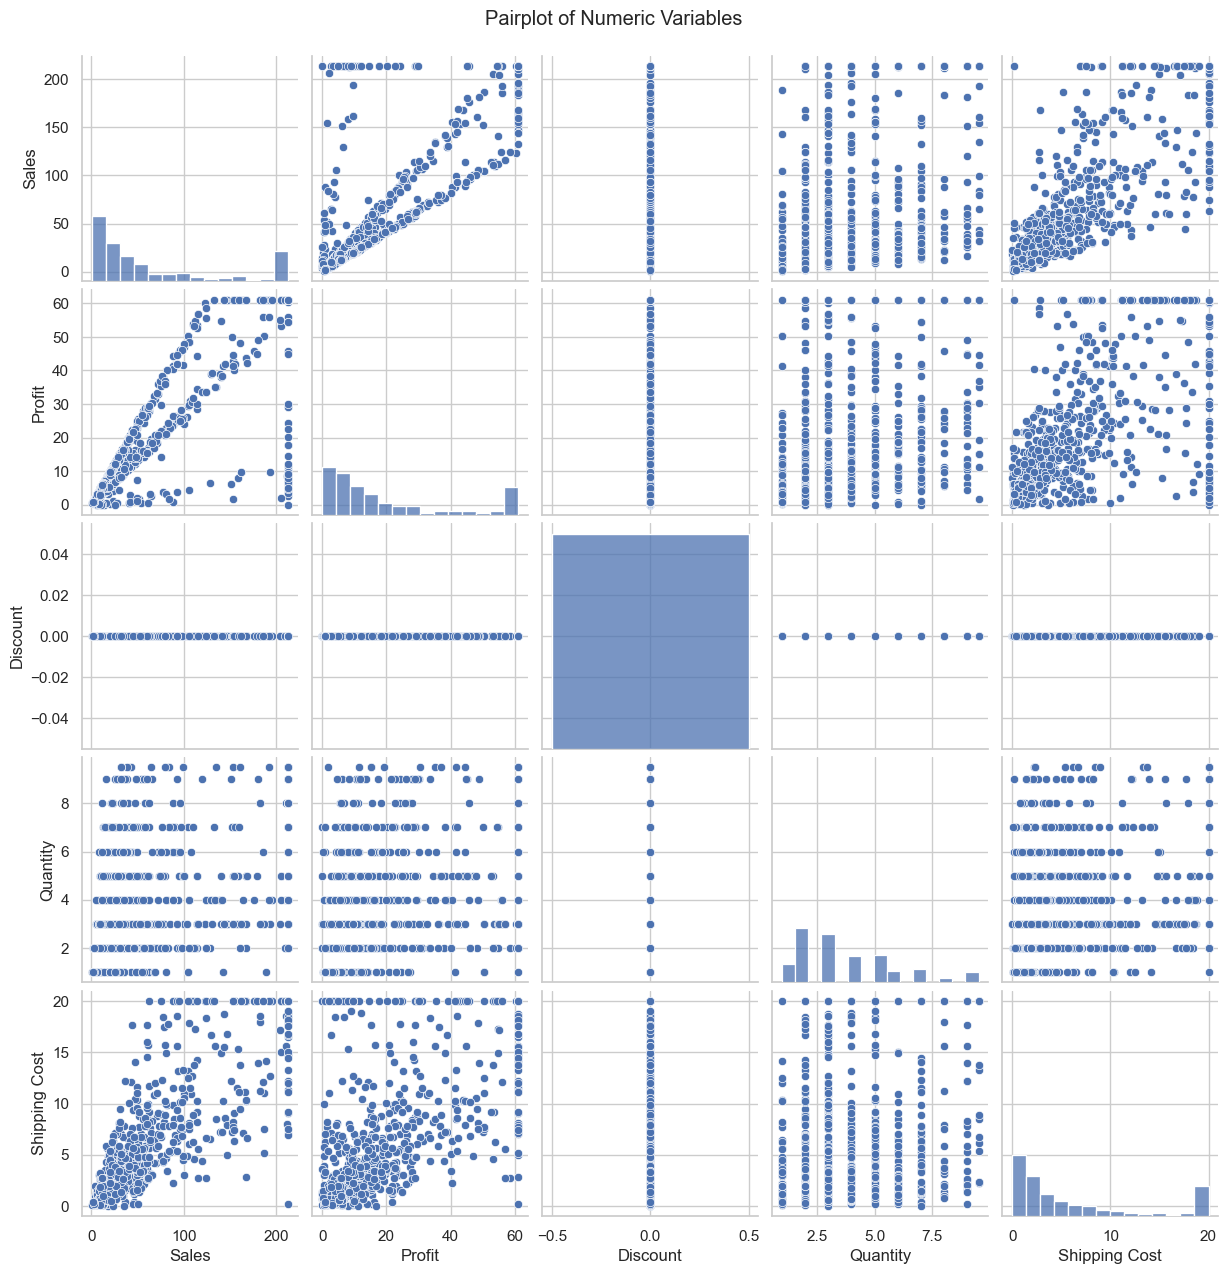

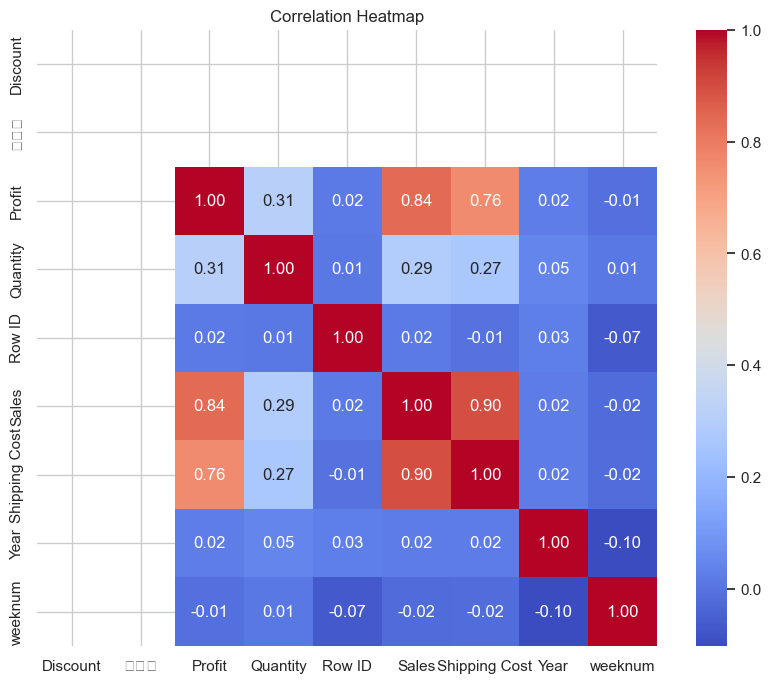

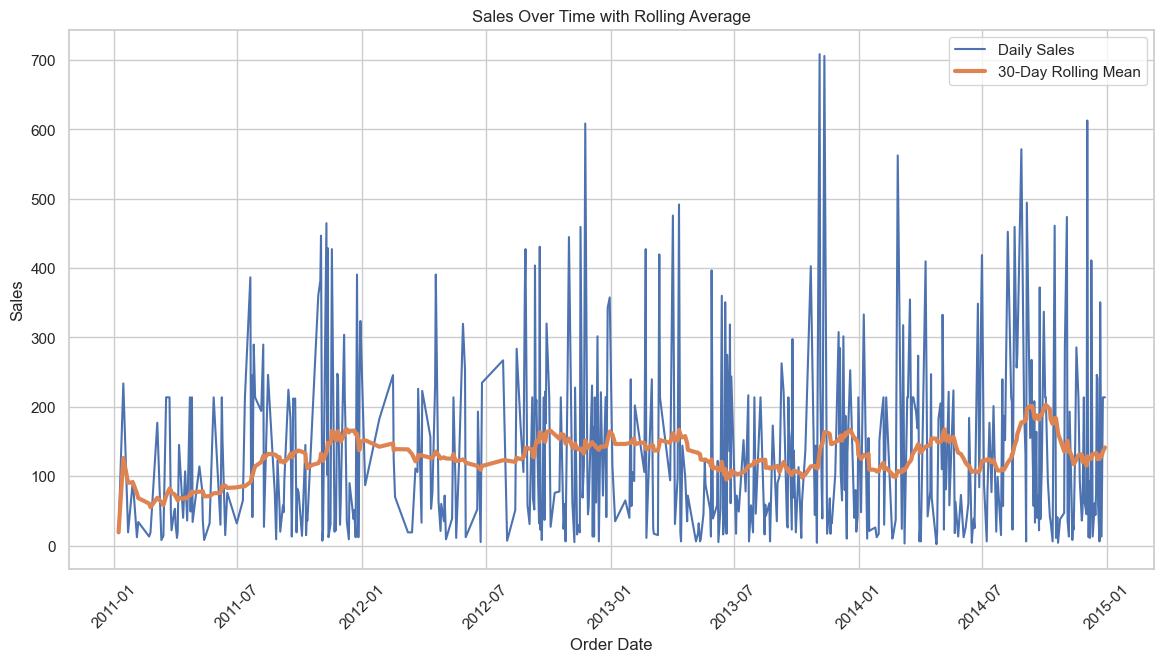

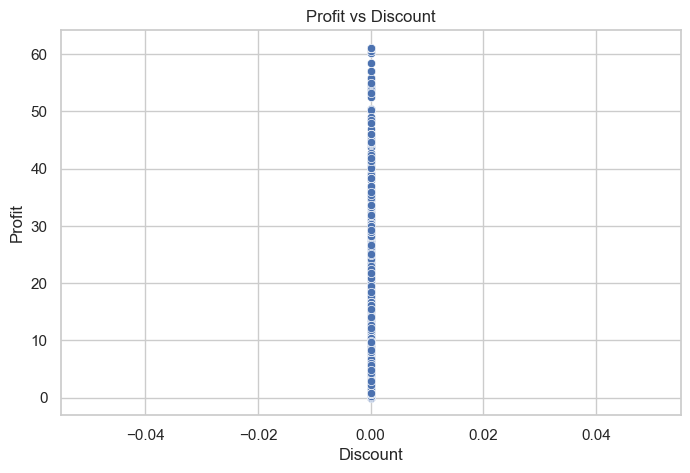

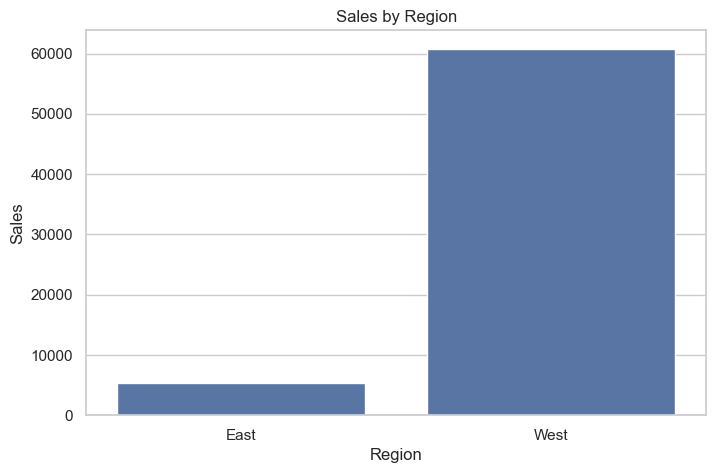

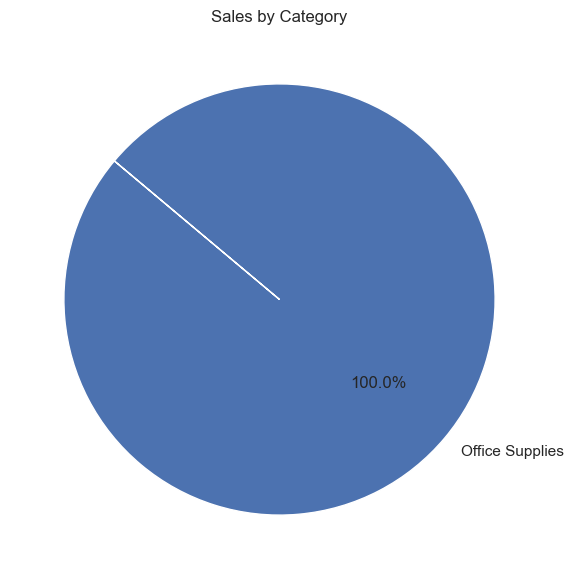

INFO:VIF values:
    feature  VIF
1    Profit  1.0
2  Discount  NaN
INFO:Cross-validation R² scores: [0.70855412 0.59092091 0.68186603 0.68349298 0.77072981]
INFO:Linear Regression Model - MSE: 1302.62, R² Score: 0.73
INFO:Coefficients: [59.35344494  0.        ]
INFO:Intercept: 66.78573233103121


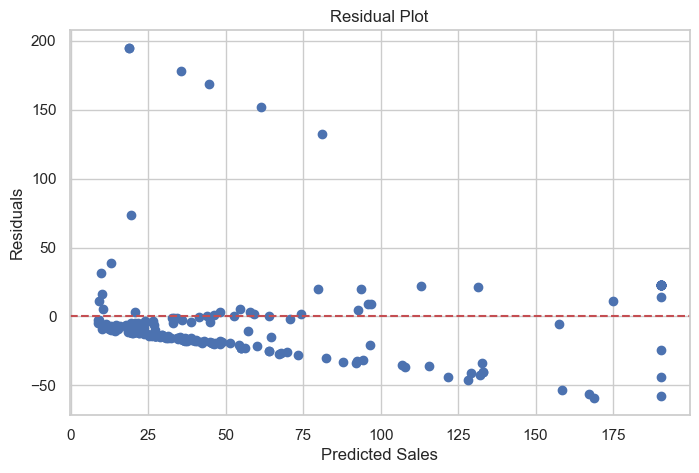

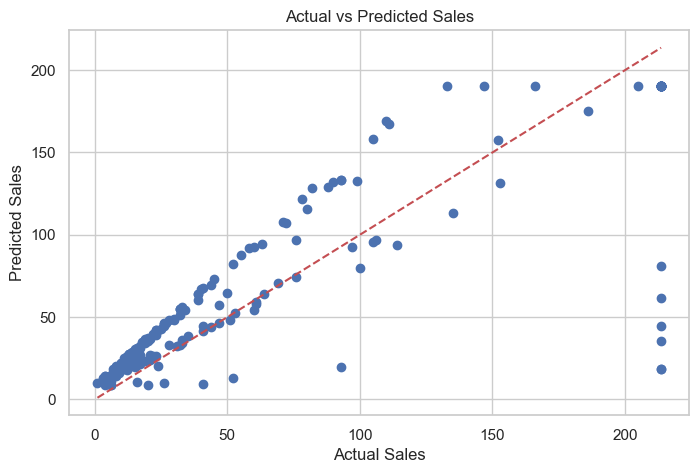

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
import logging
import warnings
warnings.filterwarnings("ignore")


logging.basicConfig(level=logging.INFO, format='%(levelname)s:%(message)s')


# Function to load and clean data
def load_and_clean_data(filepath):
    df = pd.read_csv(filepath)
    logging.info(f"Dataset loaded with shape: {df.shape}")

    # Remove duplicates
    before_dup = df.shape[0]
    df = df.drop_duplicates()
    logging.info(f"Duplicates removed: {before_dup - df.shape[0]}")

    # Handle missing values with strategy based on proportion
    for col in df.columns:
        missing_ratio = df[col].isnull().mean()
        if missing_ratio > 0:
            if df[col].dtype in ['int64', 'float64']:
                if missing_ratio > 0.3:
                    # Drop column if more than 30% missing
                    df = df.drop(columns=[col])
                    logging.warning(f"Dropped column {col} due to high missing proportion")
                else:
                    median_val = df[col].median()
                    df[col] = df[col].fillna(median_val)
                    logging.info(f"Filled missing with median for {col}")
            else:
                mode_val = df[col].mode()[0]
                df[col] = df[col].fillna(mode_val)
                logging.info(f"Filled missing with mode for {col}")

    # Convert 'Order Date' to datetime and remove invalid
    df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')
    before_date_drop = df.shape[0]
    df = df.dropna(subset=['Order Date'])
    logging.info(f"Rows dropped due to invalid dates: {before_date_drop - df.shape[0]}")

    return df


# Function to detect and cap outliers
def cap_outliers(df, cols):
    for col in cols:
        if col in df.columns:
            Q1 = df[col].quantile(0.25)
            Q3 = df[col].quantile(0.75)
            IQR = Q3 - Q1
            lower = Q1 - 1.5 * IQR
            upper = Q3 + 1.5 * IQR
            df[col] = np.where(df[col] < lower, lower, df[col])
            df[col] = np.where(df[col] > upper, upper, df[col])
            logging.info(f"Outliers capped for {col}")
    return df


# Function to compute VIF for multicollinearity check
def calculate_vif(X):
    X_const = sm.add_constant(X)
    vif = pd.DataFrame()
    vif["feature"] = X_const.columns
    vif["VIF"] = [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]
    return vif.drop(index=0)  # drop intercept


# Load and clean data
file_path = r"C:\Users\Mahendra\Downloads\sales_sample.csv"  # Update the file path as needed
df = load_and_clean_data(file_path)

# Cap outliers on numeric columns
numeric_cols = ['Sales', 'Profit', 'Discount', 'Quantity', 'Shipping Cost']
df = cap_outliers(df, numeric_cols)

# Statistical summary, skewness and kurtosis
desc_stats = df.describe()
skewness = df[numeric_cols].skew()
kurtosis = df[numeric_cols].kurtosis()
logging.info(f"Descriptive statistics:\n{desc_stats}")
logging.info(f"Skewness:\n{skewness}")
logging.info(f"Kurtosis:\n{kurtosis}")

# Visualization setup
sns.set(style="whitegrid")

# Histograms for numeric columns
for col in numeric_cols:
    if col in df.columns:
        plt.figure(figsize=(8, 4))
        sns.histplot(df[col], bins=30, kde=True)
        plt.title(f"Distribution of {col}")
        plt.show()

# Pairplot for numeric variables
sns.pairplot(df[numeric_cols].dropna())
plt.suptitle('Pairplot of Numeric Variables', y=1.02)
plt.show()

# Correlation heatmap with numeric columns only
plt.figure(figsize=(10,8))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()


# Time series plot of sales with 30-day rolling average
sales_time = df.groupby('Order Date')['Sales'].sum().reset_index()
sales_time['Sales_Rolling'] = sales_time['Sales'].rolling(window=30, min_periods=1).mean()
plt.figure(figsize=(14, 7))
plt.plot(sales_time['Order Date'], sales_time['Sales'], label='Daily Sales')
plt.plot(sales_time['Order Date'], sales_time['Sales_Rolling'], label='30-Day Rolling Mean', linewidth=3)
plt.title('Sales Over Time with Rolling Average')
plt.xlabel('Order Date')
plt.ylabel('Sales')
plt.legend()
plt.xticks(rotation=45)
plt.show()

# Scatter plot: Profit vs Discount
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Discount', y='Profit', data=df)
plt.title('Profit vs Discount')
plt.show()

# Bar plot: Sales by Region
region_sales = df.groupby('Region')['Sales'].sum().reset_index()
plt.figure(figsize=(8, 5))
sns.barplot(x='Region', y='Sales', data=region_sales)
plt.title('Sales by Region')
plt.show()

# Pie chart: Sales by Category
category_sales = df.groupby('Category')['Sales'].sum()
plt.figure(figsize=(7, 7))
category_sales.plot.pie(autopct='%1.1f%%', startangle=140)
plt.title('Sales by Category')
plt.ylabel('')
plt.show()

# Prepare features and target for modeling
X = df[['Profit', 'Discount']].copy()
y = df['Sales'].copy()

# Check multicollinearity
vif_df = calculate_vif(X)
logging.info(f"VIF values:\n{vif_df}")

# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Train linear regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Cross-validation
cv_scores = cross_val_score(lr_model, X_scaled, y, cv=5, scoring='r2')
logging.info(f"Cross-validation R² scores: {cv_scores}")

# Predict on test data
y_pred = lr_model.predict(X_test)

# Evaluation
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
logging.info(f"Linear Regression Model - MSE: {mse:.2f}, R² Score: {r2:.2f}")
logging.info(f"Coefficients: {lr_model.coef_}")
logging.info(f"Intercept: {lr_model.intercept_}")

# Residual plot for diagnostics
residuals = y_test - y_pred
plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Sales')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

# Actual vs Predicted plot
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Actual vs Predicted Sales')
plt.show()
